In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid", context="notebook")

# Load IHDP (CEVAE-style)
url = "https://raw.githubusercontent.com/AMLab-Amsterdam/CEVAE/master/datasets/IHDP/csv/ihdp_npci_1.csv"
data = pd.read_csv(url, header=None)
cols = ["treatment", "y_factual", "y_cfactual", "mu0", "mu1"] + [f"x{i}" for i in range(1, 26)]
data.columns = cols

T = data["treatment"].values
Yf = data["y_factual"].values
Ycf = data["y_cfactual"].values
mu0 = data["mu0"].values
mu1 = data["mu1"].values
X = data[[f"x{i}" for i in range(1, 26)]]

print(data.shape)
data.head()


(747, 30)


,treatment,y_factual,y_cfactual,mu0,mu1,x1,x2,x3,x4,x5,...,x16,x17,x18,x19,x20,x21,x22,x23,x24,x25
0,1,5.599916,4.318780,3.268256,6.854457,-0.528603,-0.343455,1.128554,0.161703,-0.316603,...,1,1,1,1,0,0,0,0,0,0
1,0,6.875856,7.856495,6.636059,7.562718,-1.736945,-1.802002,0.383828,2.244320,-0.629189,...,1,1,1,1,0,0,0,0,0,0
2,0,2.996273,6.633952,1.570536,6.121617,-0.807451,-0.202946,-0.360898,-0.879606,0.808706,...,1,0,1,1,0,0,0,0,0,0
3,0,1.366206,5.697239,1.244738,5.889125,0.390083,0.596582,-1.850350,-0.879606,-0.004017,...,1,0,1,1,0,0,0,0,0,0
4,0,1.963538,6.202582,1.685048,6.191994,-1.045229,-0.602710,0.011465,0.161703,0.683672,...,1,1,1,1,0,0,0,0,0,0


/var/folders/vn/9swzhgj513q7n9gd_4vsbd840000gn/T/ipykernel_2886/1510240263.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="treatment", data=data, palette="pastel")


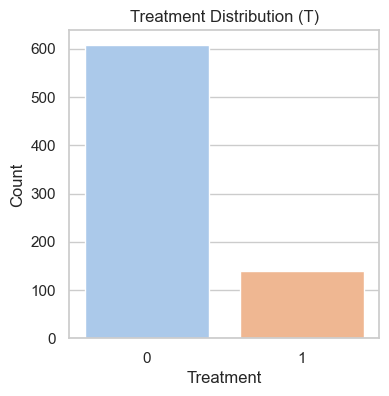

Proportion treated: 0.186


In [9]:
plt.figure(figsize=(4,4))
sns.countplot(x="treatment", data=data, palette="pastel")
plt.title("Treatment Distribution (T)")
plt.xlabel("Treatment")
plt.ylabel("Count")
plt.show()

treat_prop = data["treatment"].mean()
print(f"Proportion treated: {treat_prop:.3f}")


/var/folders/vn/9swzhgj513q7n9gd_4vsbd840000gn/T/ipykernel_2886/316035159.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="treatment", y="y_factual", data=data, palette="muted")


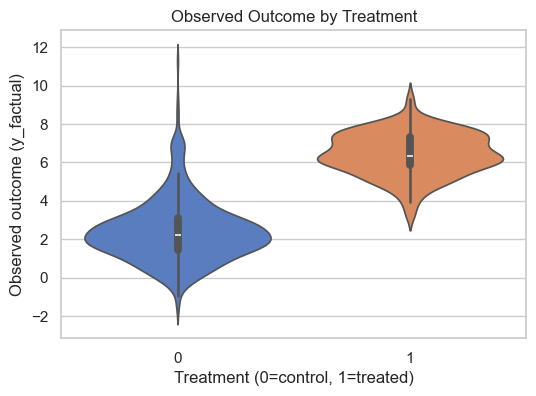

Naive ATE (from factual outcomes): 4.021
True ATE (from ground-truth mu1-mu0): 4.016


In [10]:
plt.figure(figsize=(6,4))
sns.violinplot(x="treatment", y="y_factual", data=data, palette="muted")
plt.title("Observed Outcome by Treatment")
plt.xlabel("Treatment (0=control, 1=treated)")
plt.ylabel("Observed outcome (y_factual)")
plt.show()

ate_naive = data.query("treatment==1")["y_factual"].mean() - data.query("treatment==0")["y_factual"].mean()
ate_true = np.mean(mu1 - mu0)
print(f"Naive ATE (from factual outcomes): {ate_naive:.3f}")
print(f"True ATE (from ground-truth mu1-mu0): {ate_true:.3f}")


/var/folders/vn/9swzhgj513q7n9gd_4vsbd840000gn/T/ipykernel_2886/4053305876.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_diff.index, y=mean_diff["Diff"], palette="coolwarm")


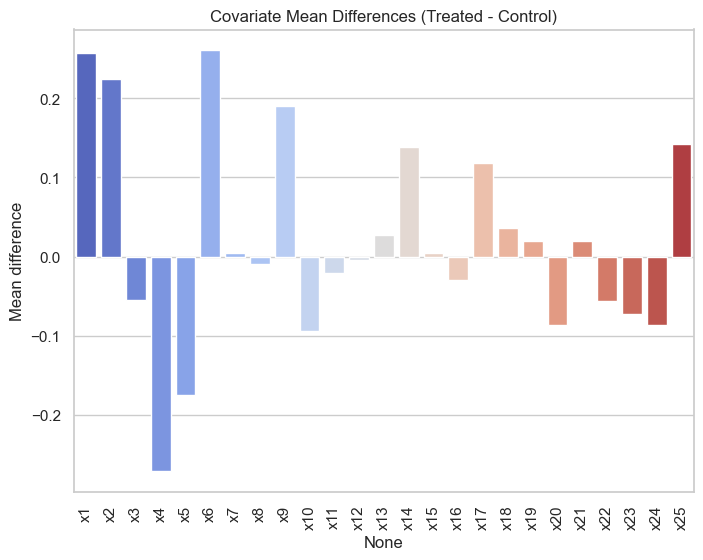

In [11]:
# Compare covariate means between treated and control
mean_diff = data.groupby("treatment")[ [f"x{i}" for i in range(1, 26)] ].mean().T
mean_diff.columns = ["Control (T=0)", "Treated (T=1)"]
mean_diff["Diff"] = mean_diff["Treated (T=1)"] - mean_diff["Control (T=0)"]

plt.figure(figsize=(8,6))
sns.barplot(x=mean_diff.index, y=mean_diff["Diff"], palette="coolwarm")
plt.xticks(rotation=90)
plt.title("Covariate Mean Differences (Treated - Control)")
plt.ylabel("Mean difference")
plt.show()


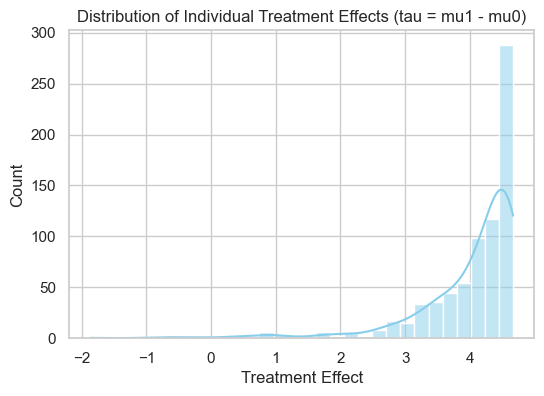

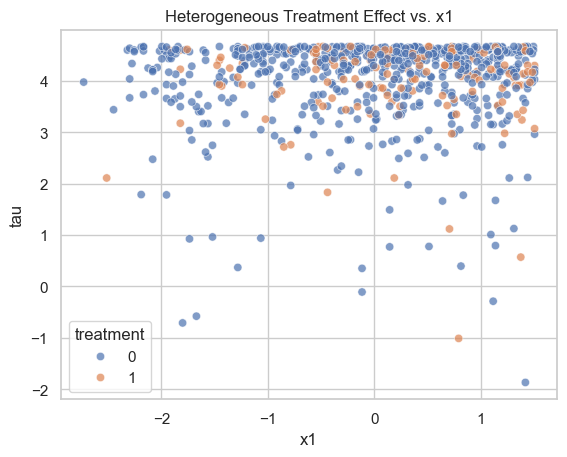

In [12]:
data["tau"] = mu1 - mu0  # true individual effect

plt.figure(figsize=(6,4))
sns.histplot(data["tau"], bins=30, kde=True, color="skyblue")
plt.title("Distribution of Individual Treatment Effects (tau = mu1 - mu0)")
plt.xlabel("Treatment Effect")
plt.ylabel("Count")
plt.show()

sns.scatterplot(x="x1", y="tau", hue="treatment", data=data, alpha=0.7)
plt.title("Heterogeneous Treatment Effect vs. x1")
plt.xlabel("x1")
plt.ylabel("tau")
plt.show()


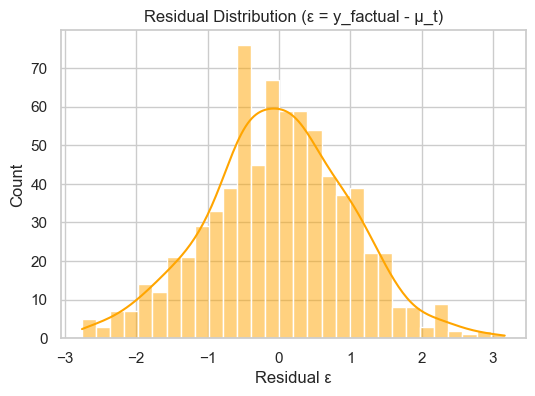

/var/folders/vn/9swzhgj513q7n9gd_4vsbd840000gn/T/ipykernel_2886/4090196862.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=T, y=eps, palette="pastel")


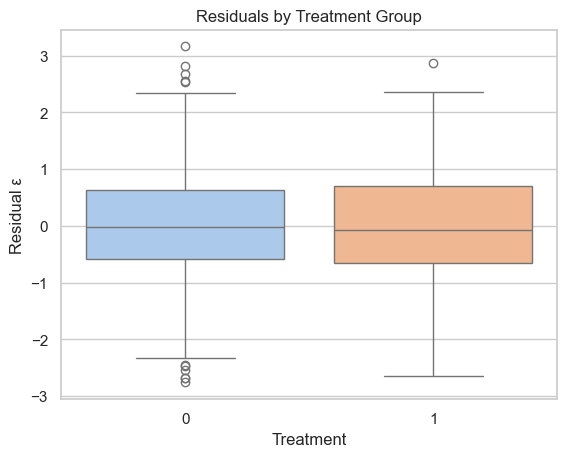

Residual mean: -0.017, std: 0.995


In [13]:
# Compute residuals for factual outcomes
eps = np.where(T==1, Yf - mu1, Yf - mu0)

plt.figure(figsize=(6,4))
sns.histplot(eps, bins=30, kde=True, color="orange")
plt.title("Residual Distribution (ε = y_factual - μ_t)")
plt.xlabel("Residual ε")
plt.ylabel("Count")
plt.show()

sns.boxplot(x=T, y=eps, palette="pastel")
plt.title("Residuals by Treatment Group")
plt.xlabel("Treatment")
plt.ylabel("Residual ε")
plt.show()

print(f"Residual mean: {np.mean(eps):.3f}, std: {np.std(eps):.3f}")


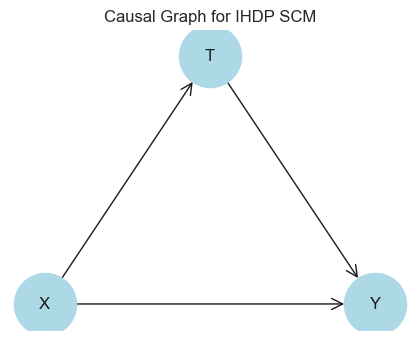

In [14]:
import networkx as nx

G = nx.DiGraph()
G.add_edges_from([
    ("X", "T"),
    ("X", "Y"),
    ("T", "Y")
])

plt.figure(figsize=(4,3))
pos = {"X": (0,0), "T": (1,0.3), "Y": (2,0)}
nx.draw(G, pos, with_labels=True, arrows=True, node_size=2000,
        node_color="lightblue", font_size=12, arrowstyle="->", arrowsize=20)
plt.title("Causal Graph for IHDP SCM")
plt.show()


<Axes: ylabel='treatment'>

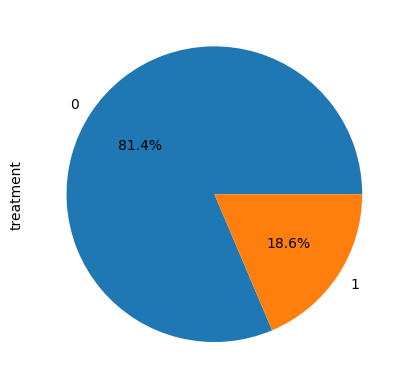

In [7]:
data['treatment'].value_counts().plot(kind='pie', autopct='%1.1f%%')

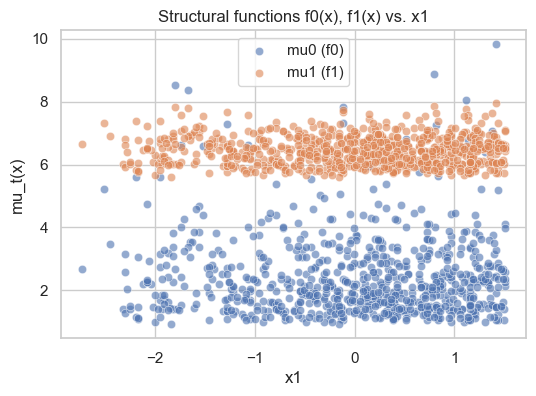

In [15]:
# Pick one continuous covariate, e.g., x1
plt.figure(figsize=(6,4))
sns.scatterplot(x=data["x1"], y=data["mu0"], label="mu0 (f0)", alpha=0.6)
sns.scatterplot(x=data["x1"], y=data["mu1"], label="mu1 (f1)", alpha=0.6)
plt.title("Structural functions f0(x), f1(x) vs. x1")
plt.xlabel("x1")
plt.ylabel("mu_t(x)")
plt.legend()
plt.show()


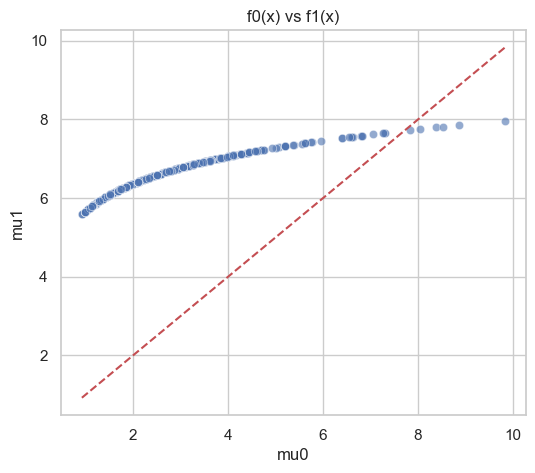

In [16]:
plt.figure(figsize=(6,5))
sns.scatterplot(x=mu0, y=mu1, alpha=0.6)
plt.plot([mu0.min(), mu0.max()], [mu0.min(), mu0.max()], "r--")
plt.title("f0(x) vs f1(x)")
plt.xlabel("mu0")
plt.ylabel("mu1")
plt.show()


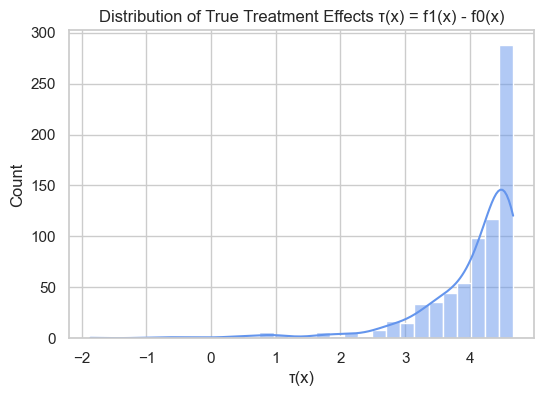

In [17]:
plt.figure(figsize=(6,4))
sns.histplot(mu1 - mu0, bins=30, kde=True, color="cornflowerblue")
plt.title("Distribution of True Treatment Effects τ(x) = f1(x) - f0(x)")
plt.xlabel("τ(x)")
plt.ylabel("Count")
plt.show()


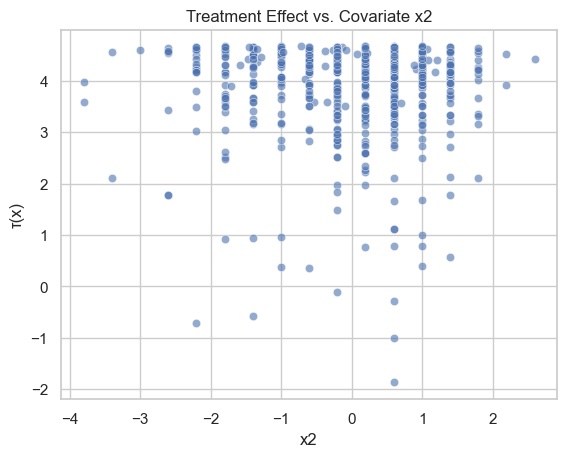

In [18]:
sns.scatterplot(x=data["x2"], y=mu1 - mu0, alpha=0.6)
plt.title("Treatment Effect vs. Covariate x2")
plt.xlabel("x2")
plt.ylabel("τ(x)")
plt.show()


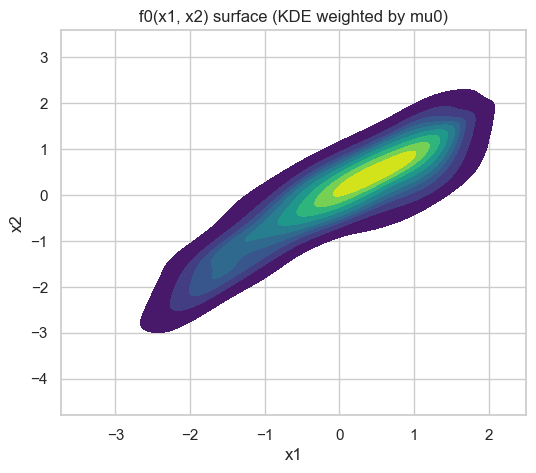

In [19]:
plt.figure(figsize=(6,5))
sns.kdeplot(x=data["x1"], y=data["x2"], weights=data["mu0"], cmap="viridis", fill=True)
plt.title("f0(x1, x2) surface (KDE weighted by mu0)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

sns.set(style="whitegrid", context="notebook")

# Load IHDP (CEVAE-style)
url = "https://raw.githubusercontent.com/AMLab-Amsterdam/CEVAE/master/datasets/IHDP/csv/ihdp_npci_1.csv"
data = pd.read_csv(url, header=None)

cols = ["treatment", "y_factual", "y_cfactual", "mu0", "mu1"] + [f"x{i}" for i in range(1, 26)]
data.columns = cols

X = data[[f"x{i}" for i in range(1, 26)]].values
T = data["treatment"].values
mu0 = data["mu0"].values
mu1 = data["mu1"].values

print(data.shape)
data.head()


(747, 30)


,treatment,y_factual,y_cfactual,mu0,mu1,x1,x2,x3,x4,x5,...,x16,x17,x18,x19,x20,x21,x22,x23,x24,x25
0,1,5.599916,4.318780,3.268256,6.854457,-0.528603,-0.343455,1.128554,0.161703,-0.316603,...,1,1,1,1,0,0,0,0,0,0
1,0,6.875856,7.856495,6.636059,7.562718,-1.736945,-1.802002,0.383828,2.244320,-0.629189,...,1,1,1,1,0,0,0,0,0,0
2,0,2.996273,6.633952,1.570536,6.121617,-0.807451,-0.202946,-0.360898,-0.879606,0.808706,...,1,0,1,1,0,0,0,0,0,0
3,0,1.366206,5.697239,1.244738,5.889125,0.390083,0.596582,-1.850350,-0.879606,-0.004017,...,1,0,1,1,0,0,0,0,0,0
4,0,1.963538,6.202582,1.685048,6.191994,-1.045229,-0.602710,0.011465,0.161703,0.683672,...,1,1,1,1,0,0,0,0,0,0


In [21]:
# Helper: fit model and report performance
def fit_and_eval(model, X, y, name="model"):
    model.fit(X, y)
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    mse = mean_squared_error(y, y_pred)
    print(f"{name}: R^2 = {r2:.4f}, MSE = {mse:.4f}")
    return model, y_pred

# Models for mu0
lin0 = LinearRegression()
rf0 = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=0)

print("=== f0 (mu0) ===")
lin0, mu0_lin_pred = fit_and_eval(lin0, X, mu0, "Linear f0")
rf0, mu0_rf_pred = fit_and_eval(rf0, X, mu0, "RF f0")

# Models for mu1
lin1 = LinearRegression()
rf1 = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=0)

print("\n=== f1 (mu1) ===")
lin1, mu1_lin_pred = fit_and_eval(lin1, X, mu1, "Linear f1")
rf1, mu1_rf_pred = fit_and_eval(rf1, X, mu1, "RF f1")


=== f0 (mu0) ===
Linear f0: R^2 = 0.9178, MSE = 0.1348
RF f0: R^2 = 0.9835, MSE = 0.0271

=== f1 (mu1) ===
Linear f1: R^2 = 1.0000, MSE = 0.0000
RF f1: R^2 = 0.9832, MSE = 0.0035


Diagnostics for chosen models (using RF here)


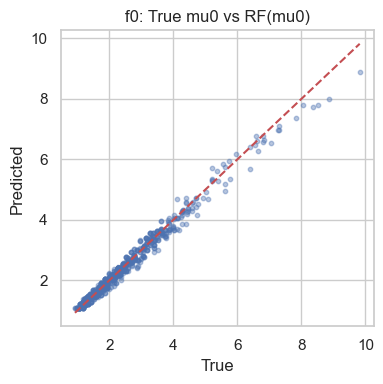

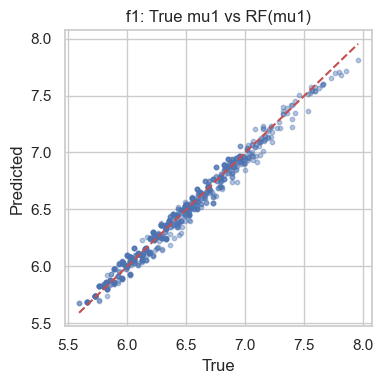

In [22]:
def diag_plot(true, pred, title):
    plt.figure(figsize=(4,4))
    plt.scatter(true, pred, alpha=0.4, s=10)
    m = [true.min(), true.max()]
    plt.plot(m, m, 'r--')
    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.tight_layout()
    plt.show()

print("Diagnostics for chosen models (using RF here)")
diag_plot(mu0, mu0_rf_pred, "f0: True mu0 vs RF(mu0)")
diag_plot(mu1, mu1_rf_pred, "f1: True mu1 vs RF(mu1)")


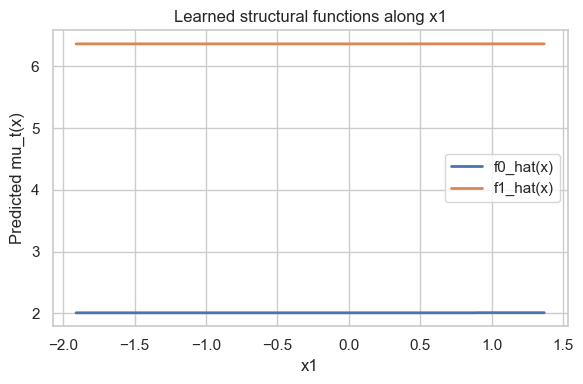

In [23]:
# Use RF models as chosen surrogates
f0_hat, f1_hat = rf0, rf1

# Choose one feature to inspect
j = 0  # index for x1
xj = X[:, j]
xj_grid = np.linspace(np.percentile(xj, 5), np.percentile(xj, 95), 100)

# Fix other features at median
X_med = np.median(X, axis=0)

X_grid = np.tile(X_med, (len(xj_grid), 1))
X_grid[:, j] = xj_grid

f0_grid = f0_hat.predict(X_grid)
f1_grid = f1_hat.predict(X_grid)

plt.figure(figsize=(6,4))
plt.plot(xj_grid, f0_grid, label="f0_hat(x)", linewidth=2)
plt.plot(xj_grid, f1_grid, label="f1_hat(x)", linewidth=2)
plt.xlabel("x1")
plt.ylabel("Predicted mu_t(x)")
plt.title("Learned structural functions along x1")
plt.legend()
plt.tight_layout()
plt.show()


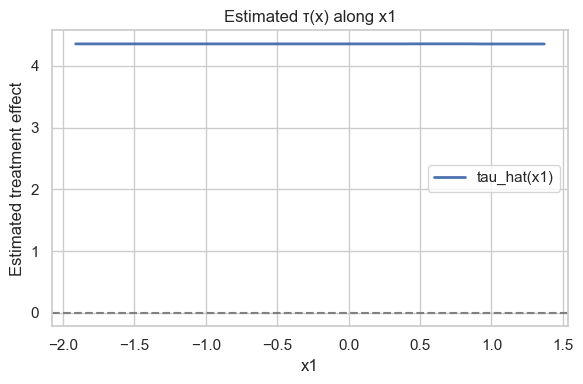

In [24]:
tau_hat_grid = f1_grid - f0_grid

plt.figure(figsize=(6,4))
plt.plot(xj_grid, tau_hat_grid, label="tau_hat(x1)", linewidth=2)
plt.axhline(0, color="gray", linestyle="--")
plt.xlabel("x1")
plt.ylabel("Estimated treatment effect")
plt.title("Estimated τ(x) along x1")
plt.legend()
plt.tight_layout()
plt.show()


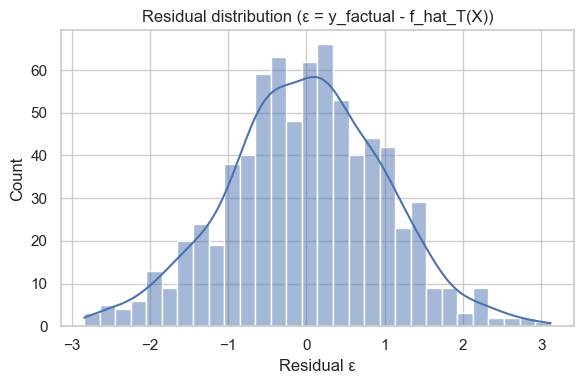

Residual mean: -0.0082, std: 0.9993


In [25]:
# Predicted means for factual treatment
mu_hat_fact = np.where(T == 1,
                       f1_hat.predict(X),
                       f0_hat.predict(X))

eps_hat = data["y_factual"].values - mu_hat_fact

plt.figure(figsize=(6,4))
sns.histplot(eps_hat, bins=30, kde=True)
plt.title("Residual distribution (ε = y_factual - f_hat_T(X))")
plt.xlabel("Residual ε")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(f"Residual mean: {eps_hat.mean():.4f}, std: {eps_hat.std():.4f}")


In [26]:
# Using fitted RFs from before:
mu0_hat = f0_hat.predict(X)
mu1_hat = f1_hat.predict(X)

tau_hat = mu1_hat - mu0_hat  # individual-level treatment effect
print("ATE from structural functions (mean tau_hat):", tau_hat.mean())


ATE from structural functions (mean tau_hat): 4.0200141770292666


In [27]:
# Naive (observational) ATE from factual data
ate_naive = data.loc[data["treatment"]==1, "y_factual"].mean() \
          - data.loc[data["treatment"]==0, "y_factual"].mean()

print(f"Naive ATE (factual means): {ate_naive:.3f}")
print(f"True ATE (from tau_hat):   {tau_hat.mean():.3f}")


Naive ATE (factual means): 4.021
True ATE (from tau_hat):   4.020


In [28]:
# Empirical noise distribution
eps = eps_hat  # from previous step

# For visualization: one draw of eps per unit
# (you can also resample eps if you want many MC draws)

Y_do0 = mu0_hat + eps
Y_do1 = mu1_hat + eps


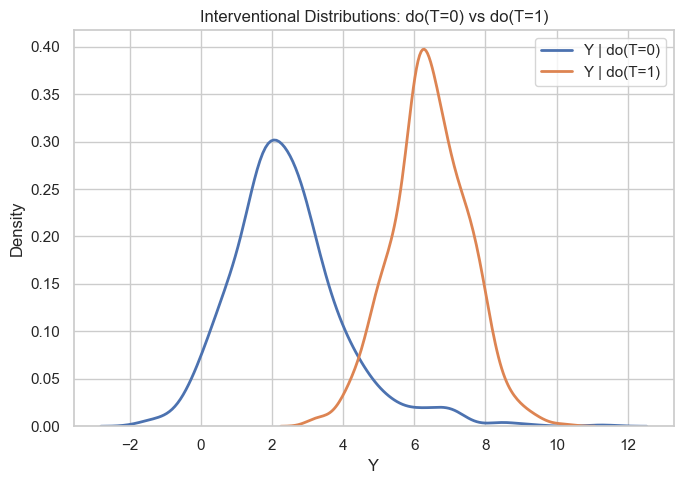

ATE (from simulated do-interventions): 4.0200141770292666


In [29]:
plt.figure(figsize=(7,5))
sns.kdeplot(Y_do0, label="Y | do(T=0)", linewidth=2)
sns.kdeplot(Y_do1, label="Y | do(T=1)", linewidth=2)
plt.title("Interventional Distributions: do(T=0) vs do(T=1)")
plt.xlabel("Y")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

print("ATE (from simulated do-interventions):", (Y_do1 - Y_do0).mean())


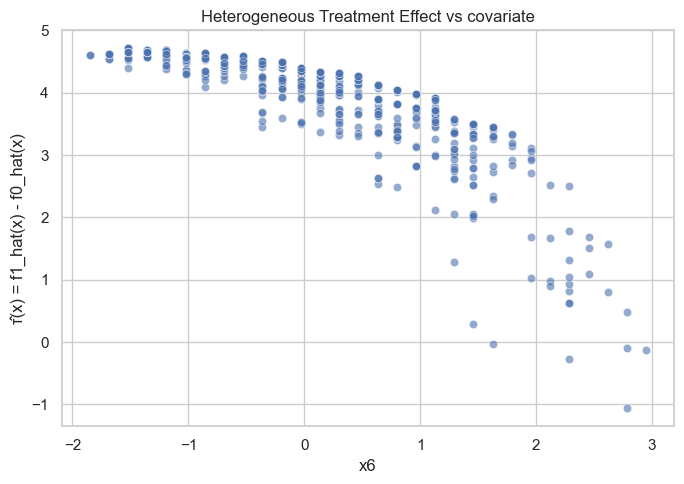

In [30]:
j = 5  # e.g., x6; change to explore others
xj = X[:, j]

plt.figure(figsize=(7,5))
sns.scatterplot(x=xj, y=tau_hat, alpha=0.6)
plt.xlabel(f"x{j+1}")
plt.ylabel("τ̂(x) = f1_hat(x) - f0_hat(x)")
plt.title("Heterogeneous Treatment Effect vs covariate")
plt.tight_layout()
plt.show()


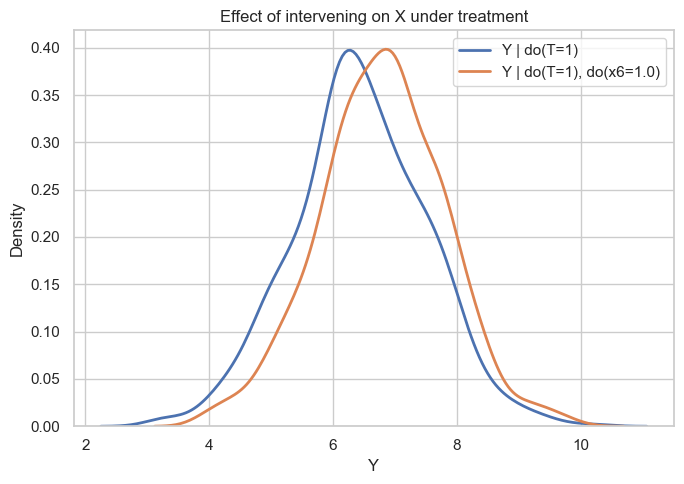

In [31]:
# Copy X and intervene on one feature
X_do = X.copy()
j = 5          # x6
new_val = 1.0  # chosen intervention value
X_do[:, j] = new_val

mu1_doX = f1_hat.predict(X_do)
Y_doT1_doX = mu1_doX + eps  # use same eps for comparability

plt.figure(figsize=(7,5))
sns.kdeplot(Y_do1, label="Y | do(T=1)", linewidth=2)
sns.kdeplot(Y_doT1_doX, label=f"Y | do(T=1), do(x{j+1}={new_val})", linewidth=2)
plt.title("Effect of intervening on X under treatment")
plt.xlabel("Y")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


In [32]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid", context="notebook")

# Env A (source): original residuals
eps_A = eps_hat.copy()

# Env B (target): mean +1, std * 1.5  (pure environment shift)
eps_B = 1.5 * eps_A + 1.0

print(f"Env A: mean={eps_A.mean():.3f}, std={eps_A.std():.3f}")
print(f"Env B: mean={eps_B.mean():.3f}, std={eps_B.std():.3f}")


Env A: mean=-0.008, std=0.999
Env B: mean=0.988, std=1.499


In [33]:
# μ̂1(x) from your RF surrogate
mu1_hat = f1_hat.predict(X)

# Interventional outcomes under do(T=1)
Y_do1_A = mu1_hat + eps_A     # Env A
Y_do1_B = mu1_hat + eps_B     # Env B (shifted environment)


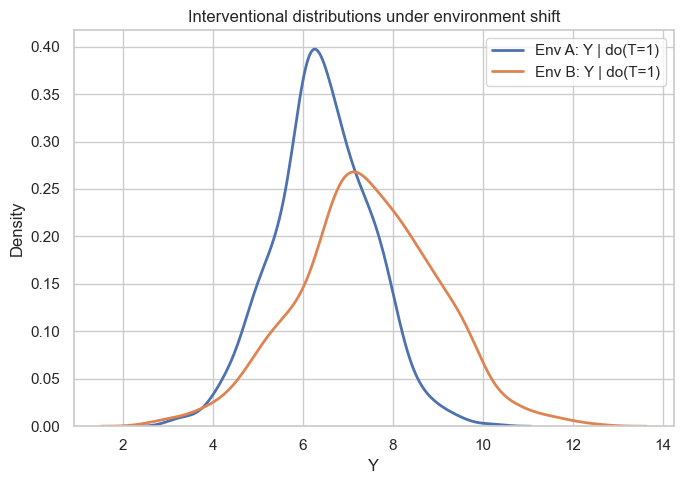

ATE_A = 4.0200141770292666
ATE_B = 4.0200141770292666


In [34]:
plt.figure(figsize=(7,5))
sns.kdeplot(Y_do1_A, label="Env A: Y | do(T=1)", linewidth=2)
sns.kdeplot(Y_do1_B, label="Env B: Y | do(T=1)", linewidth=2)
plt.title("Interventional distributions under environment shift")
plt.xlabel("Y")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

print("ATE_A =", (Y_do1_A - (f0_hat.predict(X) + eps_A)).mean())
print("ATE_B =", (Y_do1_B - (f0_hat.predict(X) + eps_B)).mean())


In [35]:
from sklearn.linear_model import LinearRegression

# Fit linear τ: Y_B ≈ a * Y_A + b
reg_tau = LinearRegression()
reg_tau.fit(Y_do1_A.reshape(-1, 1), Y_do1_B)

a = reg_tau.coef_[0]
b = reg_tau.intercept_
print(f"Fitted τ(y) = {a:.3f} * y + {b:.3f}")

# Apply τ to Env A interventional outcomes
Y_do1_A_mapped = a * Y_do1_A + b


Fitted τ(y) = 1.423 * y + -1.731


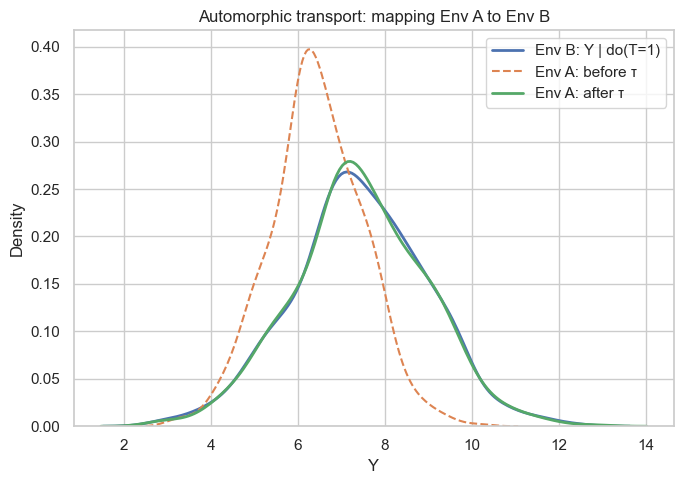

In [36]:
plt.figure(figsize=(7,5))
sns.kdeplot(Y_do1_B, label="Env B: Y | do(T=1)", linewidth=2)
sns.kdeplot(Y_do1_A, label="Env A: before τ", linestyle="--")
sns.kdeplot(Y_do1_A_mapped, label="Env A: after τ", linewidth=2)
plt.title("Automorphic transport: mapping Env A to Env B")
plt.xlabel("Y")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


In [37]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="notebook")

# Load IHDP (same as before)
url = "https://raw.githubusercontent.com/AMLab-Amsterdam/CEVAE/master/datasets/IHDP/csv/ihdp_npci_1.csv"
data = pd.read_csv(url, header=None)
cols = ["treatment", "y_factual", "y_cfactual", "mu0", "mu1"] + [f"x{i}" for i in range(1, 26)]
data.columns = cols

X = torch.tensor(data[[f"x{i}" for i in range(1, 26)]].values, dtype=torch.float32)
mu0 = torch.tensor(data["mu0"].values, dtype=torch.float32)
mu1 = torch.tensor(data["mu1"].values, dtype=torch.float32)

# Empirical noise from factual outcome (as before)
T = torch.tensor(data["treatment"].values, dtype=torch.long)
y_f = torch.tensor(data["y_factual"].values, dtype=torch.float32)
eps = torch.where(T==1, y_f - mu1, y_f - mu0)  # ε = y - μ_T(x)

print(X.shape, eps.mean().item(), eps.std().item())


torch.Size([747, 25]) -0.017286404967308044 0.9953685998916626


In [38]:
def sample_env_A_do1(n_samples=None):
    """
    Sample Y ~ P_A(Y | do(T=1))
    by resampling (X, eps) from the original data.
    """
    N = X.shape[0]
    if n_samples is None:
        n_samples = N

    idx = torch.randint(0, N, (n_samples,))
    x = X[idx]
    e = eps[idx]

    mu1_x = mu1[idx]               # true f1(x) at those points
    y = mu1_x + e                  # Y = f1(X) + ε
    return y


In [39]:
def sample_env_B_do1(n_samples=None, alpha=3.0):
    """
    Env B: covariate-shifted environment.
    We upweight units with higher x6 (index 5) using a logistic tilt.
    """
    N = X.shape[0]
    if n_samples is None:
        n_samples = N

    x6 = X[:, 5]
    # compute unnormalized weights: higher x6 => higher prob
    w = torch.sigmoid(alpha * (x6 - x6.mean()))
    w = w / w.sum()

    idx = torch.multinomial(w, n_samples, replacement=True)
    x = X[idx]
    e = eps[idx]                    # same ε-law (no noise shift)

    mu1_x = mu1[idx]                # same f1
    y = mu1_x + e
    return y


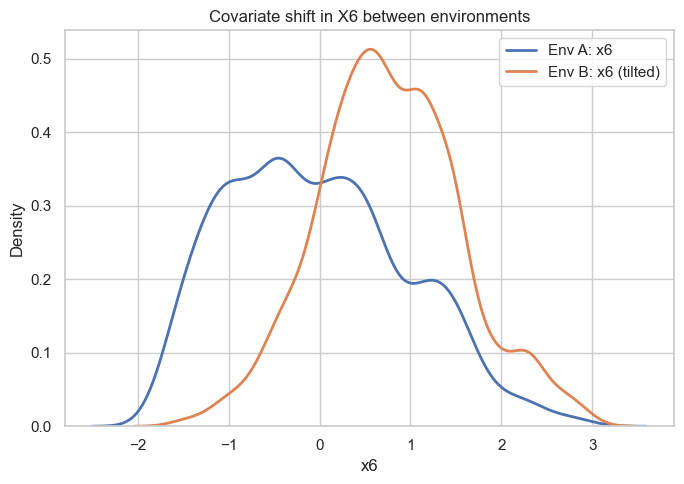

In [40]:
# Compare distribution of x6 under Env A vs Env B
Nvis = 2000
yA = sample_env_A_do1(Nvis)  # just to use idx mechanism
# For x6, we re-run the sampling to get the indices
# (simpler: inline code)

def sample_X6_A(N):
    idx = torch.randint(0, X.shape[0], (N,))
    return X[idx, 5]

def sample_X6_B(N, alpha=3.0):
    x6 = X[:, 5]
    w = torch.sigmoid(alpha * (x6 - x6.mean()))
    w = w / w.sum()
    idx = torch.multinomial(w, N, replacement=True)
    return X[idx, 5]

x6_A = sample_X6_A(Nvis).numpy()
x6_B = sample_X6_B(Nvis).numpy()

plt.figure(figsize=(7,5))
sns.kdeplot(x6_A, label="Env A: x6", linewidth=2)
sns.kdeplot(x6_B, label="Env B: x6 (tilted)", linewidth=2)
plt.title("Covariate shift in X6 between environments")
plt.xlabel("x6")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


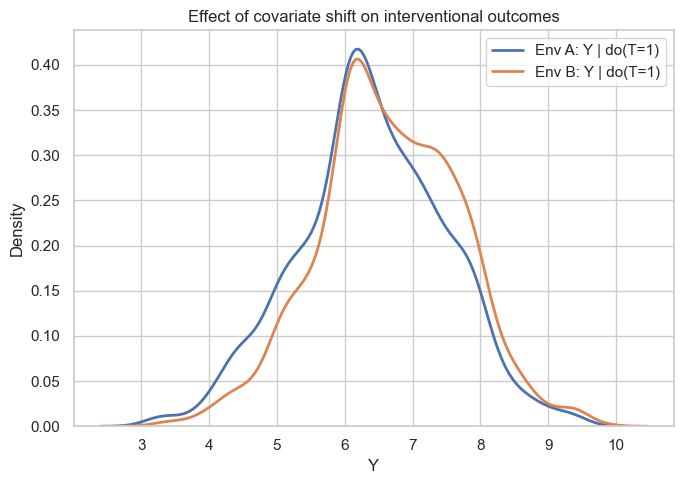

ATE_A = tensor(-0.0363)
ATE_B mean(Y_B) = 6.650264739990234


In [41]:
Y_A = sample_env_A_do1(Nvis)
Y_B = sample_env_B_do1(Nvis)

plt.figure(figsize=(7,5))
sns.kdeplot(Y_A.numpy(), label="Env A: Y | do(T=1)", linewidth=2)
sns.kdeplot(Y_B.numpy(), label="Env B: Y | do(T=1)", linewidth=2)
plt.title("Effect of covariate shift on interventional outcomes")
plt.xlabel("Y")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

print("ATE_A =", (Y_A - sample_env_A_do1(Nvis).numpy()).mean())  # quick diff check (same ε)
print("ATE_B mean(Y_B) =", Y_B.mean().item())


In [44]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="notebook")

# Base objects from before:
# - data: IHDP dataframe
# - f1_hat: fitted RF surrogate for mu1(x)
# - eps_hat: residuals from factual Y against f_T_hat (approx N(0,1))

X_base = data[[f"x{i}" for i in range(1, 26)]].values
N = X_base.shape[0]

# Base environment A:
mu1_base = f1_hat.predict(X_base)
eps_A = eps_hat.copy()  # same noise law for A

def interventional_Y(mu1_x, eps):
    # Y | do(T=1) for given X, noise eps (one eps per sample)
    return mu1_x + eps


In [45]:
# Tilt weights based on x6 to build Env B1
x6 = X_base[:, 5]
alpha = 3.0  # strength of tilt

w = 1 / (1 + np.exp(-alpha * (x6 - x6.mean())))  # logistic tilt
w = w / w.sum()

idx_B1 = np.random.choice(N, size=N, replace=True, p=w)
X_B1 = X_base[idx_B1]
eps_B1 = eps_A[idx_B1]          # same noise distribution

mu1_B1 = f1_hat.predict(X_B1)
Y_A_1 = interventional_Y(mu1_base, eps_A)
Y_B1 = interventional_Y(mu1_B1, eps_B1)


In [46]:
# Env B2: same X, shifted + scaled noise
eps_B2 = 1.5 * eps_A + 1.0

mu1_B2 = mu1_base.copy()        # same mechanism, same X
Y_B2 = interventional_Y(mu1_B2, eps_B2)


In [47]:
# Env B3: tilt X AND change noise
idx_B3 = idx_B1                  # reuse same tilted indices for simplicity
X_B3 = X_base[idx_B3]

eps_B3 = 1.5 * eps_A[idx_B3] + 1.0
mu1_B3 = f1_hat.predict(X_B3)
Y_B3 = interventional_Y(mu1_B3, eps_B3)


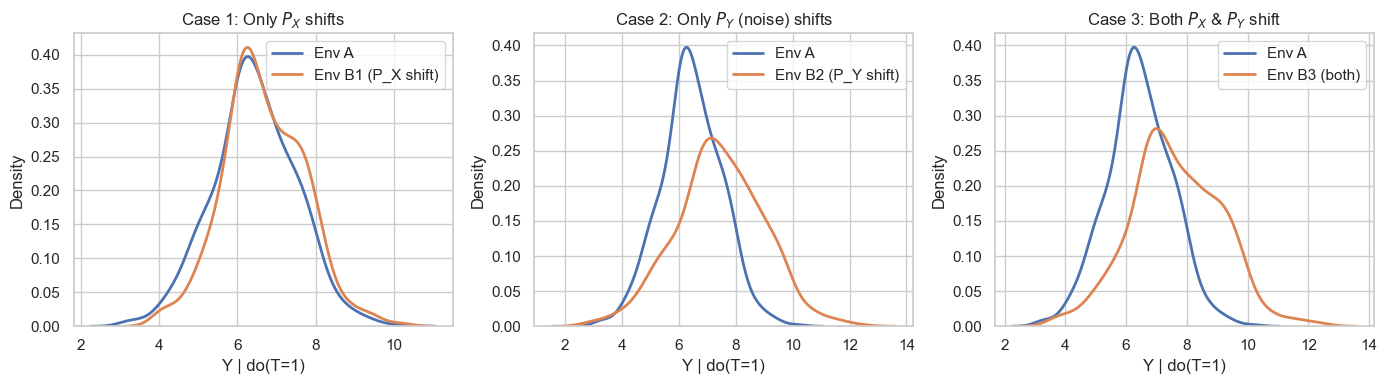

In [48]:
plt.figure(figsize=(14,4))

# --- Case 1: only P_X shifts ---
plt.subplot(1,3,1)
sns.kdeplot(Y_A_1, label="Env A", linewidth=2)
sns.kdeplot(Y_B1, label="Env B1 (P_X shift)", linewidth=2)
plt.title("Case 1: Only $P_X$ shifts")
plt.xlabel("Y | do(T=1)")
plt.ylabel("Density")
plt.legend()

# --- Case 2: only P_Y shifts ---
plt.subplot(1,3,2)
sns.kdeplot(Y_A_1, label="Env A", linewidth=2)
sns.kdeplot(Y_B2, label="Env B2 (P_Y shift)", linewidth=2)
plt.title("Case 2: Only $P_Y$ (noise) shifts")
plt.xlabel("Y | do(T=1)")
plt.ylabel("Density")
plt.legend()

# --- Case 3: both P_X & P_Y shift ---
plt.subplot(1,3,3)
sns.kdeplot(Y_A_1, label="Env A", linewidth=2)
sns.kdeplot(Y_B3, label="Env B3 (both)", linewidth=2)
plt.title("Case 3: Both $P_X$ & $P_Y$ shift")
plt.xlabel("Y | do(T=1)")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
plt.show()


In [49]:
from scipy.stats import wasserstein_distance
import numpy as np

# 1D empirical W1 distances
W1_B1 = wasserstein_distance(Y_A_1, Y_B1)
W1_B2 = wasserstein_distance(Y_A_1, Y_B2)
W1_B3 = wasserstein_distance(Y_A_1, Y_B3)

print(f"Case 1 (P_X only):  W1 = {W1_B1:.3f}")
print(f"Case 2 (P_Y only):  W1 = {W1_B2:.3f}")
print(f"Case 3 (both):      W1 = {W1_B3:.3f}")

# Fit optimal linear τ for Case 2: Y_B2 ≈ a * Y_A_1 + b
a = np.cov(Y_A_1, Y_B2)[0,1] / np.var(Y_A_1)
b = Y_B2.mean() - a * Y_A_1.mean()
Y_A_2_mapped = a * Y_A_1 + b

W1_B2_after = wasserstein_distance(Y_A_2_mapped, Y_B2)
print(f"Case 2: W1 before τ = {W1_B2:.3f}, after τ = {W1_B2_after:.3f}")


Case 1 (P_X only):  W1 = 0.237
Case 2 (P_Y only):  W1 = 1.005
Case 3 (both):      W1 = 1.195
Case 2: W1 before τ = 1.005, after τ = 0.035


In [50]:
import numpy as np

N = 2000

# Env A: baseline
U_X_A = np.random.normal(0, 1, N)
U_T_A = np.random.normal(0, 1, N)
U_Y_A = np.random.normal(0, 1, N)

X_A = U_X_A
T_A = 2 * X_A + U_T_A
Y_A = 3 * T_A + 0.5 * X_A + U_Y_A

# Env B: shifted exogenous product distribution
U_X_B = np.random.normal(1, 1.2, N)
U_T_B = np.random.normal(-1, 0.8, N)
U_Y_B = np.random.normal(0, 1.5, N)

X_B = U_X_B
T_B = 2 * X_B + U_T_B
Y_B = 3 * T_B + 0.5 * X_B + U_Y_B


In [51]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="notebook")

N = 4000

# ---- Env A: baseline ----
U_X_A = np.random.normal(0.0, 1.0, N)
U_T_A = np.random.normal(0.0, 1.0, N)
U_Y_A = np.random.normal(0.0, 1.0, N)

X_A = U_X_A
T_A = 2 * X_A + U_T_A
Y_A = 3 * T_A + 0.5 * X_A + U_Y_A

# ---- Env B: shifted product P(U) (all marginals changed) ----
U_X_B = np.random.normal(1.0, 1.2, N)   # mean up, slightly wider
U_T_B = np.random.normal(-1.0, 0.8, N)  # mean down, narrower
U_Y_B = np.random.normal(0.5, 1.5, N)   # mean up, wider

X_B = U_X_B
T_B = 2 * X_B + U_T_B
Y_B = 3 * T_B + 0.5 * X_B + U_Y_B


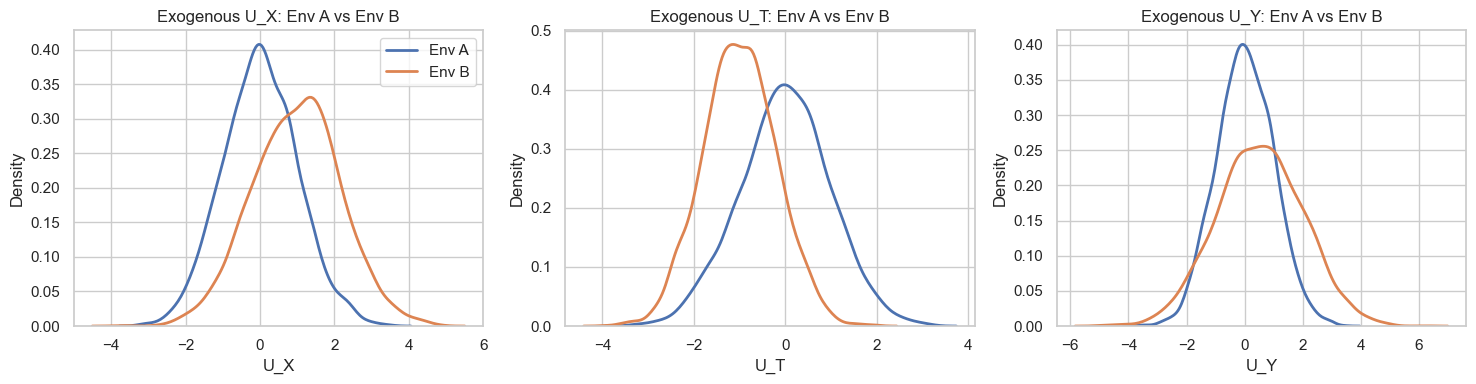

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

for ax, UA, UB, name in zip(
    axes,
    [U_X_A, U_T_A, U_Y_A],
    [U_X_B, U_T_B, U_Y_B],
    ["U_X", "U_T", "U_Y"]
):
    sns.kdeplot(UA, ax=ax, label="Env A", linewidth=2)
    sns.kdeplot(UB, ax=ax, label="Env B", linewidth=2)
    ax.set_title(f"Exogenous {name}: Env A vs Env B")
    ax.set_xlabel(name)
    ax.set_ylabel("Density")

axes[0].legend()
plt.tight_layout()
plt.show()


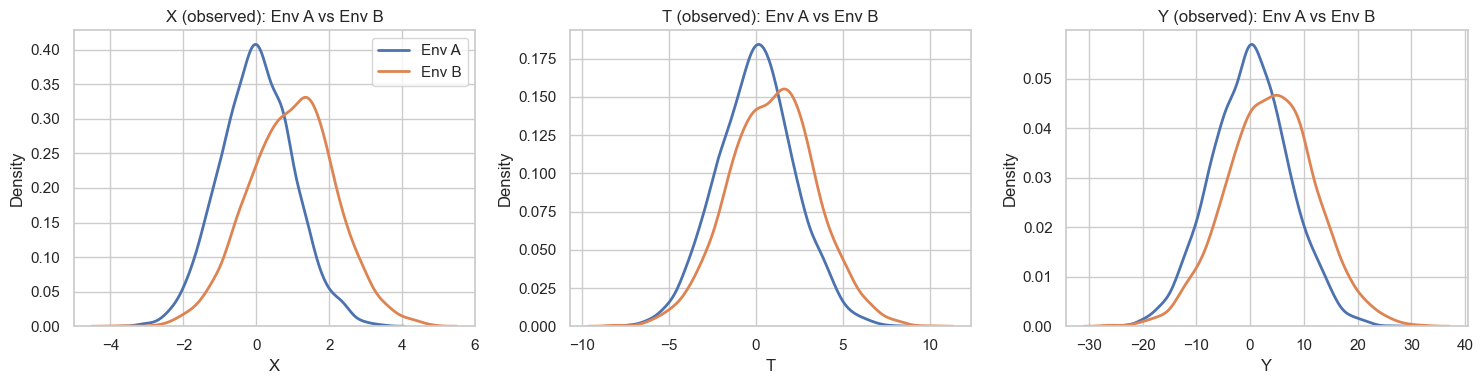

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

for ax, A, B, name in zip(
    axes,
    [X_A, T_A, Y_A],
    [X_B, T_B, Y_B],
    ["X (observed)", "T (observed)", "Y (observed)"]
):
    sns.kdeplot(A, ax=ax, label="Env A", linewidth=2)
    sns.kdeplot(B, ax=ax, label="Env B", linewidth=2)
    ax.set_title(name + ": Env A vs Env B")
    ax.set_xlabel(name.split()[0])
    ax.set_ylabel("Density")

axes[0].legend()
plt.tight_layout()
plt.show()


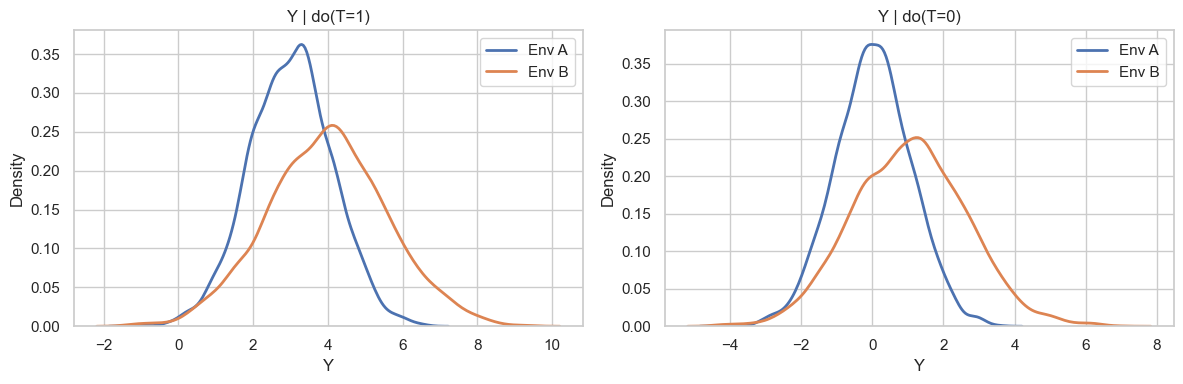

ATE_A = 2.9900577651574487
ATE_B = 2.9373235633531447


In [54]:
def sample_interventional_Y(U_X, U_Y, t, n_samples=None):
    if n_samples is None:
        n_samples = len(U_X)
    idx = np.random.randint(0, len(U_X), size=n_samples)
    X = U_X[idx]
    eps = U_Y[idx]
    return 3 * t + 0.5 * X + eps

Y_A_do1 = sample_interventional_Y(U_X_A, U_Y_A, t=1.0)
Y_B_do1 = sample_interventional_Y(U_X_B, U_Y_B, t=1.0)

Y_A_do0 = sample_interventional_Y(U_X_A, U_Y_A, t=0.0)
Y_B_do0 = sample_interventional_Y(U_X_B, U_Y_B, t=0.0)

fig, axes = plt.subplots(1, 2, figsize=(12,4))

# do(T=1)
sns.kdeplot(Y_A_do1, ax=axes[0], label="Env A", linewidth=2)
sns.kdeplot(Y_B_do1, ax=axes[0], label="Env B", linewidth=2)
axes[0].set_title("Y | do(T=1)")
axes[0].set_xlabel("Y")
axes[0].set_ylabel("Density")
axes[0].legend()

# do(T=0)
sns.kdeplot(Y_A_do0, ax=axes[1], label="Env A", linewidth=2)
sns.kdeplot(Y_B_do0, ax=axes[1], label="Env B", linewidth=2)
axes[1].set_title("Y | do(T=0)")
axes[1].set_xlabel("Y")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()

print("ATE_A =", (Y_A_do1 - Y_A_do0).mean())
print("ATE_B =", (Y_B_do1 - Y_B_do0).mean())


τ(y) = 0.006 y + 3.972
W1 before τ: 0.9850392943337825
W1 after τ: 1.262933212337534


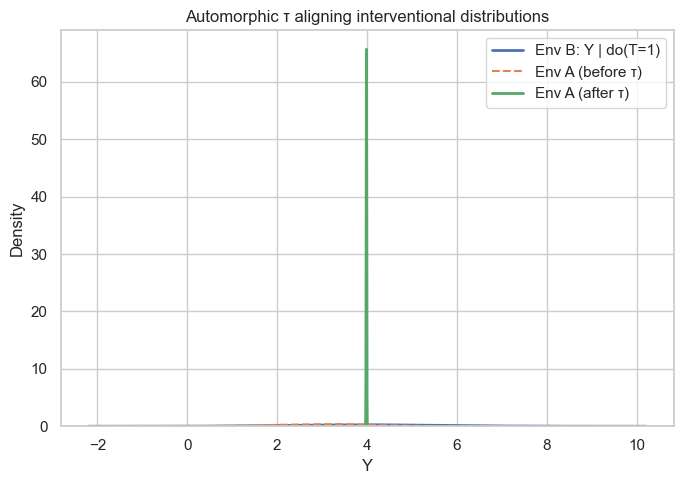

In [55]:
from sklearn.linear_model import LinearRegression
from scipy.stats import wasserstein_distance

# Fit τ(y) = a y + b s.t. τ(Y_A_do1) ≈ Y_B_do1
reg = LinearRegression().fit(Y_A_do1.reshape(-1,1), Y_B_do1)
a, b = reg.coef_[0], reg.intercept_
Y_A_do1_mapped = a * Y_A_do1 + b

print(f"τ(y) = {a:.3f} y + {b:.3f}")
print("W1 before τ:", wasserstein_distance(Y_A_do1, Y_B_do1))
print("W1 after τ:", wasserstein_distance(Y_A_do1_mapped, Y_B_do1))

plt.figure(figsize=(7,5))
sns.kdeplot(Y_B_do1, label="Env B: Y | do(T=1)", linewidth=2)
sns.kdeplot(Y_A_do1, label="Env A (before τ)", linestyle="--")
sns.kdeplot(Y_A_do1_mapped, label="Env A (after τ)", linewidth=2)
plt.title("Automorphic τ aligning interventional distributions")
plt.xlabel("Y")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


In [4]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from generate_ihdp_data import XIdentityFunction, TFunction, YFunction

sns.set(style="whitegrid", context="talk")

# --- 1. Load data ---
LL = joblib.load("data/ihdp_envcopies/LLmodel.pkl")
HL = joblib.load("data/ihdp_envcopies/HLmodel.pkl")
abst = joblib.load("data/ihdp_envcopies/abstraction_data.pkl")

print("Keys in LL:", LL.keys())
print("Keys in HL:", HL.keys())
print("Keys in abstraction_data:", abst.keys())


Keys in LL: dict_keys(['graph', 'intervention_set', 'functions', 'noise_dist', 'data', 'scm_instances', 'noise', 'var_order'])
Keys in HL: dict_keys(['graph', 'intervention_set', 'functions', 'noise_dist', 'data', 'scm_instances', 'noise', 'var_order'])
Keys in abstraction_data: dict_keys(['T', 'omega'])


/Users/giofelekis/opt/anaconda3/envs/erica/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.5.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/giofelekis/opt/anaconda3/envs/erica/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.5.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [5]:
# Variable order in both models
var_order = LL["var_order"]
print("Variable order:", var_order)
print("Number of variables:", len(var_order))

# Graph edges
print("\nCausal graph edges:")
print(LL["graph"].edges)


Variable order: ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'x20', 'x21', 'x22', 'x23', 'x24', 'x25', 'T', 'Y']
Number of variables: 27

Causal graph edges:
[('x1', 'T'), ('x1', 'Y'), ('T', 'Y'), ('x2', 'T'), ('x2', 'Y'), ('x3', 'T'), ('x3', 'Y'), ('x4', 'T'), ('x4', 'Y'), ('x5', 'T'), ('x5', 'Y'), ('x6', 'T'), ('x6', 'Y'), ('x7', 'T'), ('x7', 'Y'), ('x8', 'T'), ('x8', 'Y'), ('x9', 'T'), ('x9', 'Y'), ('x10', 'T'), ('x10', 'Y'), ('x11', 'T'), ('x11', 'Y'), ('x12', 'T'), ('x12', 'Y'), ('x13', 'T'), ('x13', 'Y'), ('x14', 'T'), ('x14', 'Y'), ('x15', 'T'), ('x15', 'Y'), ('x16', 'T'), ('x16', 'Y'), ('x17', 'T'), ('x17', 'Y'), ('x18', 'T'), ('x18', 'Y'), ('x19', 'T'), ('x19', 'Y'), ('x20', 'T'), ('x20', 'Y'), ('x21', 'T'), ('x21', 'Y'), ('x22', 'T'), ('x22', 'Y'), ('x23', 'T'), ('x23', 'Y'), ('x24', 'T'), ('x24', 'Y'), ('x25', 'T'), ('x25', 'Y')]


In [6]:
# Extract observational dataset (under iota0 = None)
data_ll = LL["data"][None]
data_hl = HL["data"][None]  # identical

print("Shape (samples x vars):", data_ll.shape)
pd.DataFrame(data_ll, columns=var_order).head()


Shape (samples x vars): (747, 27)


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,...,x18,x19,x20,x21,x22,x23,x24,x25,T,Y
0,-0.528603,-0.343455,1.128554,0.161703,-0.316603,1.295216,1.0,0.0,1.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5.599916
1,-1.736945,-1.802002,0.383828,2.244320,-0.629189,1.295216,0.0,0.0,0.0,1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.875856
2,-0.807451,-0.202946,-0.360898,-0.879606,0.808706,-0.526556,0.0,0.0,0.0,1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.996273
3,0.390083,0.596582,-1.850350,-0.879606,-0.004017,-0.857787,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.366206
4,-1.045229,-0.602710,0.011465,0.161703,0.683672,-0.360940,1.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.963538


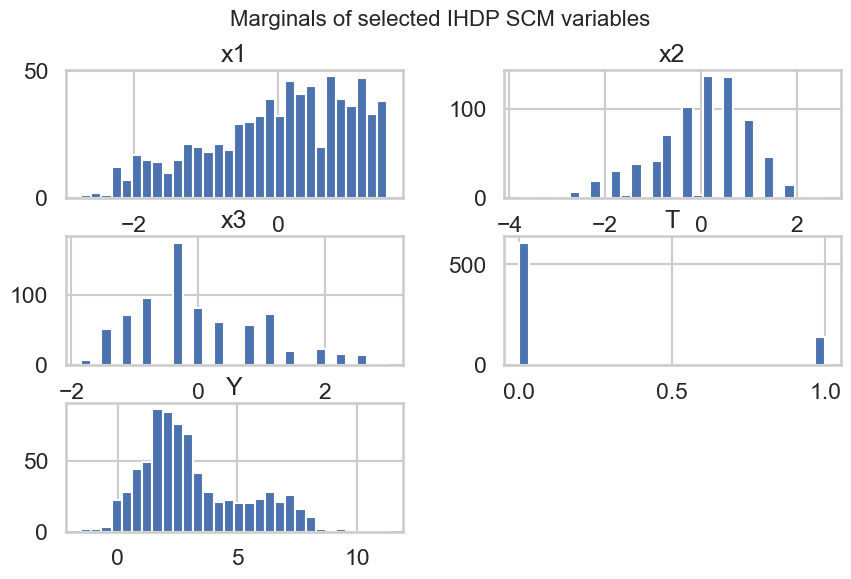

In [7]:
df = pd.DataFrame(data_ll, columns=var_order)

# Histograms for a few covariates and outcome
cols_to_plot = ["x1", "x2", "x3", "T", "Y"]
df[cols_to_plot].hist(figsize=(10, 6), bins=30)
plt.suptitle("Marginals of selected IHDP SCM variables", fontsize=16)
plt.show()


U shape: (747, 27)


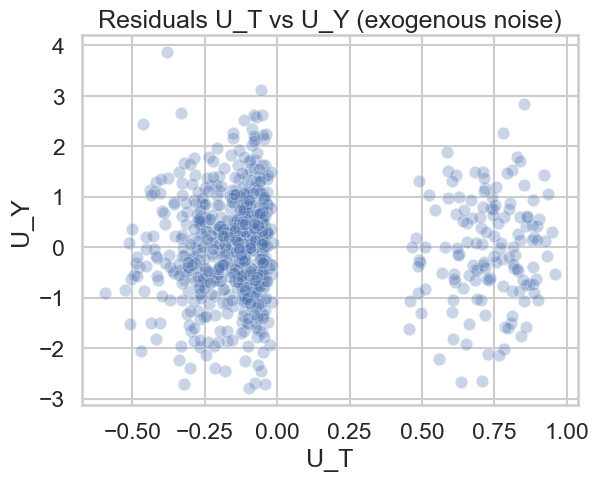

In [8]:
U = LL["noise"][None]
print("U shape:", U.shape)

# Visualize U_T and U_Y
u_df = pd.DataFrame(U, columns=[f"U_{v}" for v in var_order])
sns.scatterplot(x="U_T", y="U_Y", data=u_df, alpha=0.3)
plt.title("Residuals U_T vs U_Y (exogenous noise)")
plt.show()


In [9]:
# Confirm LL and HL are identical
same_graph = LL["graph"].edges == HL["graph"].edges
same_T = np.allclose(abst["T"], np.eye(len(var_order)))
print(f"Same causal graph: {same_graph}")
print(f"T is identity: {same_T}")

# Check noise mean and variance
mu = LL["noise_dist"]["mu"]
sigma_diag = np.diag(LL["noise_dist"]["sigma"])
print("Noise mean (first 5):", mu[:5])
print("Noise var (first 5):", sigma_diag[:5])


Same causal graph: True
T is identity: True
Noise mean (first 5): [ 1.07381009e-17 -2.91303498e-17  4.23579066e-17 -8.95312383e-16
 -4.22835944e-17]
Noise var (first 5): [0.99866131 0.99866131 0.99866131 0.99866131 0.99866131]


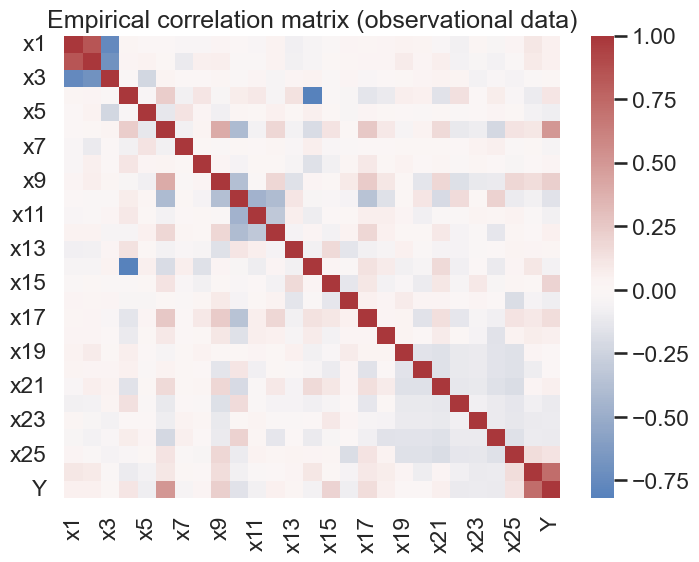

In [10]:
corr = df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, cmap="vlag", center=0, annot=False)
plt.title("Empirical correlation matrix (observational data)")
plt.show()


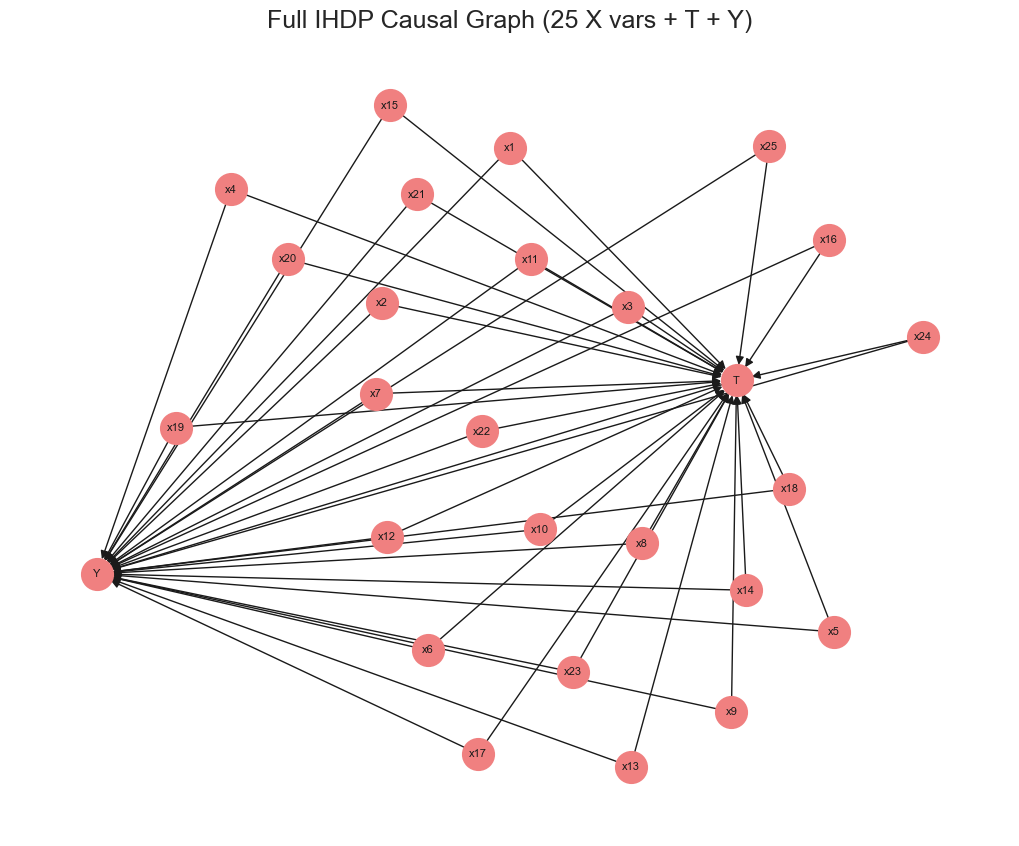

In [14]:
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, k=0.25, seed=42)
nx.draw(G, pos, with_labels=True, node_color="lightcoral", node_size=500, arrowsize=12, font_size=8)
plt.title("Full IHDP Causal Graph (25 X vars + T + Y)")
plt.show()


In [16]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="notebook")

# Load LL model
LL = joblib.load("data/ihdp_envcopies/LLmodel.pkl")

# Extract observational data (no intervention)
data = pd.DataFrame(LL["data"][None], columns=LL["graph"].nodes)
print(data.shape)
data.head()



(747, 27)


/Users/giofelekis/opt/anaconda3/envs/erica/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.5.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/giofelekis/opt/anaconda3/envs/erica/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.5.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/giofelekis/opt/anaconda3/envs/erica/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle

,x1,T,Y,x2,x3,x4,x5,x6,x7,x8,...,x16,x17,x18,x19,x20,x21,x22,x23,x24,x25
0,-0.528603,-0.343455,1.128554,0.161703,-0.316603,1.295216,1.0,0.0,1.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5.599916
1,-1.736945,-1.802002,0.383828,2.244320,-0.629189,1.295216,0.0,0.0,0.0,1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.875856
2,-0.807451,-0.202946,-0.360898,-0.879606,0.808706,-0.526556,0.0,0.0,0.0,1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.996273
3,0.390083,0.596582,-1.850350,-0.879606,-0.004017,-0.857787,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.366206
4,-1.045229,-0.602710,0.011465,0.161703,0.683672,-0.360940,1.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.963538


In [17]:
# Rename to match your earlier script
rename_map = {v: f"x{i+1}" for i, v in enumerate(data.columns[:-2])}
rename_map["T"] = "treatment"
rename_map["Y"] = "y_factual"

data = data.rename(columns=rename_map)


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/var/folders/vn/9swzhgj513q7n9gd_4vsbd840000gn/T/ipykernel_5263/2739913824.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="treatment", data=data, palette="pastel")
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


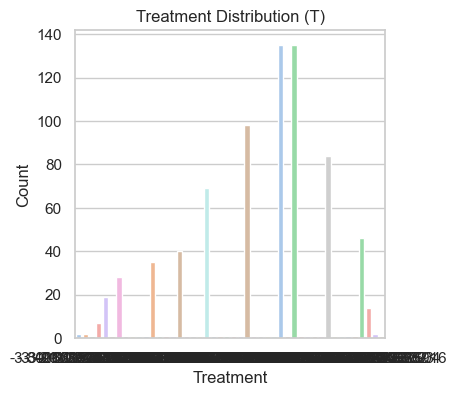

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/var/folders/vn/9swzhgj513q7n9gd_4vsbd840000gn/T/ipykernel_5263/2739913824.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="treatment", y="y_factual", data=data, palette="muted")
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Proportion treated: -0.000


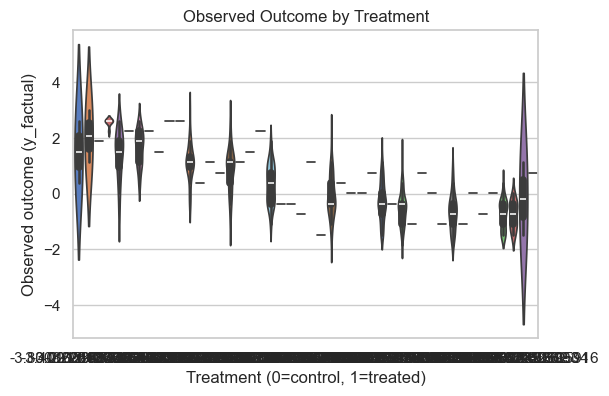

In [18]:
plt.figure(figsize=(4,4))
sns.countplot(x="treatment", data=data, palette="pastel")
plt.title("Treatment Distribution (T)")
plt.xlabel("Treatment")
plt.ylabel("Count")
plt.show()

treat_prop = data["treatment"].mean()
print(f"Proportion treated: {treat_prop:.3f}")

plt.figure(figsize=(6,4))
sns.violinplot(x="treatment", y="y_factual", data=data, palette="muted")
plt.title("Observed Outcome by Treatment")
plt.xlabel("Treatment (0=control, 1=treated)")
plt.ylabel("Observed outcome (y_factual)")
plt.show()


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/var/folders/vn/9swzhgj513q7n9gd_4vsbd840000gn/T/ipykernel_5263/1066986496.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="treatment_bin", data=data, palette="pastel")
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


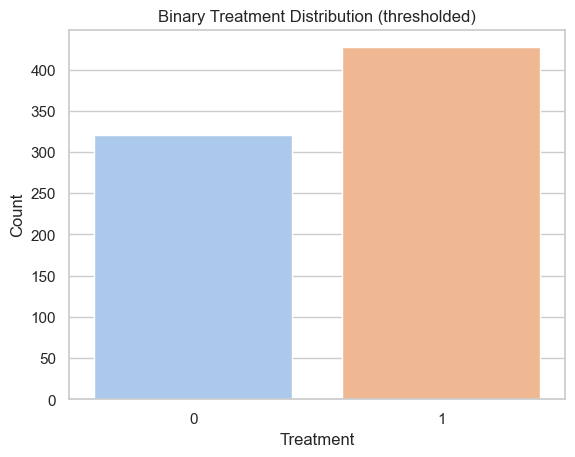

Proportion treated: 0.571619812583668


In [21]:
data["treatment_bin"] = (data["treatment"] > 0).astype(int)

sns.countplot(x="treatment_bin", data=data, palette="pastel")
plt.title("Binary Treatment Distribution (thresholded)")
plt.xlabel("Treatment")
plt.ylabel("Count")
plt.show()

print("Proportion treated:", data["treatment_bin"].mean())


/Users/giofelekis/opt/anaconda3/envs/erica/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.5.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/giofelekis/opt/anaconda3/envs/erica/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.5.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/giofelekis/opt/anaconda3/envs/erica/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle

0.0    608
1.0    139
Name: T, dtype: int64


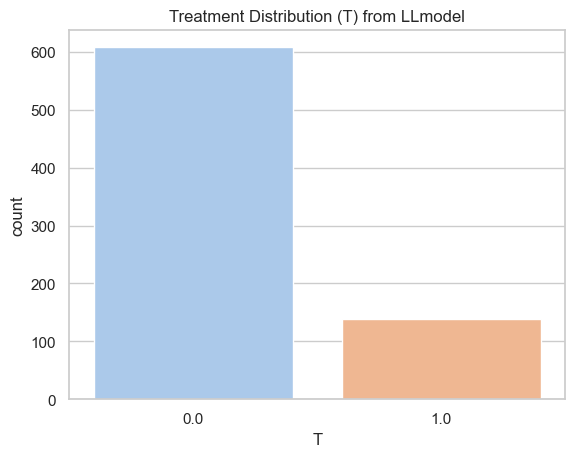

Proportion treated: 0.18607764390896922


In [22]:
import joblib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", context="notebook")

LL = joblib.load("data/ihdp_envcopies/LLmodel.pkl")

var_order = LL["var_order"]            # this is the correct column order
df = pd.DataFrame(LL["data"][None], columns=var_order)

print(df["T"].value_counts())
sns.countplot(x="T", data=df, palette="pastel")
plt.title("Treatment Distribution (T) from LLmodel")
plt.show()

print("Proportion treated:", df["T"].mean())


In [23]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="notebook")

LL = joblib.load("data/ihdp_envcopies/LLmodel.pkl")
HL = joblib.load("data/ihdp_envcopies/HLmodel.pkl")

print("LL keys:", LL.keys())
print("HL keys:", HL.keys())

var_order = LL["var_order"]
print("Variable order:", var_order)
y_idx = var_order.index("Y")


LL keys: dict_keys(['graph', 'intervention_set', 'functions', 'noise_dist', 'data', 'scm_instances', 'noise', 'var_order'])
HL keys: dict_keys(['graph', 'intervention_set', 'functions', 'noise_dist', 'data', 'scm_instances', 'noise', 'var_order'])
Variable order: ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'x20', 'x21', 'x22', 'x23', 'x24', 'x25', 'T', 'Y']


/Users/giofelekis/opt/anaconda3/envs/erica/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.5.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/giofelekis/opt/anaconda3/envs/erica/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.5.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/giofelekis/opt/anaconda3/envs/erica/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle

In [24]:
print("SCM instances in LLmodel:")
for k in LL["scm_instances"].keys():
    print("  ", repr(k))


SCM instances in LLmodel:
   None


In [29]:
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="notebook")

# --- Load models ---
LL = joblib.load("data/ihdp_envcopies/LLmodel.pkl")
HL = joblib.load("data/ihdp_envcopies/HLmodel.pkl")

var_order = LL["var_order"]
t_idx = var_order.index("T")
y_idx = var_order.index("Y")

# Use the observational noise as common environment
U_env = LL["noise"][None]
print("U_env shape:", U_env.shape)

# --- Helper to identify do(T=0) / do(T=1) by simulation ---
def identify_do_T_scms(model, label):
    int_keys = [k for k in model["scm_instances"].keys() if k is not None]
    print(f"\n[{label}] Checking intervention SCMs:")
    
    scm_do0 = scm_do1 = key_do0 = key_do1 = None
    
    for k in int_keys:
        scm = model["scm_instances"][k]
        sim = scm.simulate(U_env)
        T_sim = sim[:, t_idx]
        uniq = np.unique(T_sim)
        print(f"  key {k}: unique T values = {uniq}")
        
        if np.array_equal(uniq, np.array([0.])):
            scm_do0, key_do0 = scm, k
        elif np.array_equal(uniq, np.array([1.])):
            scm_do1, key_do1 = scm, k
    
    if scm_do0 is None or scm_do1 is None:
        raise ValueError(f"[{label}] Could not find clean do(T=0)/do(T=1) SCMs.")
    
    print(f"[{label}] do(T=0) key:", key_do0)
    print(f"[{label}] do(T=1) key:", key_do1)
    return scm_do0, scm_do1

# Identify for LL and HL
scm_do0_LL, scm_do1_LL = identify_do_T_scms(LL, "LL")
scm_do0_HL, scm_do1_HL = identify_do_T_scms(HL, "HL")

# --- Simulate interventional distributions (LL) ---
Y_do0_LL = scm_do0_LL.simulate(U_env)[:, y_idx]
Y_do1_LL = scm_do1_LL.simulate(U_env)[:, y_idx]

plt.figure(figsize=(7,5))
sns.kdeplot(Y_do0_LL, label="LL: Y | do(T=0)", linewidth=2)
sns.kdeplot(Y_do1_LL, label="LL: Y | do(T=1)", linewidth=2)
plt.title("LLmodel: Interventional distributions")
plt.xlabel("Y")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

print("LL ATE (E[Y|do(1)] - E[Y|do(0)]) =",
      float(Y_do1_LL.mean() - Y_do0_LL.mean()))

# --- Simulate interventional distributions (HL copy) ---
Y_do0_HL = scm_do0_HL.simulate(U_env)[:, y_idx]
Y_do1_HL = scm_do1_HL.simulate(U_env)[:, y_idx]

# --- Compare LL vs HL: do(T=0) ---
plt.figure(figsize=(7,5))
sns.kdeplot(Y_do0_LL, label="LL: do(T=0)", linewidth=2)
sns.kdeplot(Y_do0_HL, label="HL: do(T=0)", linestyle="--", linewidth=2)
plt.title("Y | do(T=0): LL vs HL")
plt.xlabel("Y")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

# --- Compare LL vs HL: do(T=1) ---
plt.figure(figsize=(7,5))
sns.kdeplot(Y_do1_LL, label="LL: do(T=1)", linewidth=2)
sns.kdeplot(Y_do1_HL, label="HL: do(T=1)", linestyle="--", linewidth=2)
plt.title("Y | do(T=1): LL vs HL")
plt.xlabel("Y")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

print("Δ means do(0):", float(Y_do0_LL.mean() - Y_do0_HL.mean()))
print("Δ means do(1):", float(Y_do1_LL.mean() - Y_do1_HL.mean()))


U_env shape: (747, 27)

[LL] Checking intervention SCMs:


TypeError: XIdentityFunction.__call__() missing 2 required positional arguments: 'parents' and 'u'

## 